In [2]:
import torch
import os
import sys
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

project_root = "/home/kkarthik/ARD/sam3"
sys.path.append(project_root)

from omegaconf import OmegaConf
from sam3 import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.model.box_ops import box_xywh_to_cxcywh
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results
import torchvision.transforms as T
import torch
from tqdm import tqdm
import json
import numpy as np
import torch
import pycocotools.mask as mask_util 
from scipy.optimize import linear_sum_assignment
import numpy as np

def build_annotation_index(image_id):
    annotations_list = coco_data['annotations']
    annotations_of_image = []
    
    for ann in annotations_list:
        if ann['image_id'] == image_id:
            annotations_of_image.append(ann)
        
    return annotations_of_image

def decode_rle_masks(annotations):
    gt_masks = []
    gt_rles = []
    
    for ann in annotations:
        seg = ann['segmentation']
        gt_rles.append(seg)
        
    gt_masks_np = mask_util.decode(gt_rles) 
    return gt_masks_np

def calculate_iou(mask_a, mask_b):    
    intersection = np.logical_and(mask_a, mask_b).sum()
    union = np.logical_or(mask_a, mask_b).sum()
    
    if union == 0:
        return 0.0
    
    iou = intersection / union
    return iou

In [3]:
# /mnt/harddrive/data/dataset/sam3_format/coco_annotations.json
import json

# with open('/mnt/harddrive/data/dataset/sam3_format/coco_annotations.json', 'r') as f:
with open('/home/kkarthik/ARD/AIProjects/segment-anything-2/sam2/modeling/backbones/coco_merged2.json', 'r') as f:
    coco_data = json.load(f)

In [4]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import random
import numpy as np
from PIL import Image
import os

def generate_point_grids_inside_mask(mask, point_spacing=32):
    h, w = mask.shape
    ys = np.arange(0, h, point_spacing)
    xs = np.arange(0, w, point_spacing)

    grid_points = []
    for y in ys:
        for x in xs:
            if mask[y, x] != 0:
                grid_points.append([x / w, y / h])  # Normalize to [0, 1]

    return np.array(grid_points)

def overlay_masks_with_points(image, result, point_grids=None):
    """
    Overlays all masks on the image with unique colors, optionally overlays prompt points,
    and annotates each mask with its index and point_coords.
    """
    alpha = 0.5
    overlay = image.copy()
    h, w, _ = image.shape

    # Generate distinct random colors for each mask
    num_masks = len(result)
    random.seed(23)
    colors = random.choices(list(mcolors.CSS4_COLORS.values()), k=num_masks)
    color_map = [np.array(mcolors.to_rgb(c)) * 255 for c in colors]

    # Blend each mask with a color
    for i, r in enumerate(result):
        mask = r["segmentation"]
        color = color_map[i]
        for c in range(3):
            overlay[:, :, c] = np.where(
                mask,
                (1 - alpha) * overlay[:, :, c] + alpha * color[c],
                overlay[:, :, c]
            )

    # Plot the overlayed image
    plt.figure(figsize=(10, 10))
    plt.imshow(overlay.astype(np.uint8))

    # Annotate mask indices at their centroids
    for i, r in enumerate(result):
        mask = r["segmentation"]
        y_indices, x_indices = np.where(mask)
        if len(x_indices) > 0 and len(y_indices) > 0:
            cx, cy = int(np.mean(x_indices)), int(np.mean(y_indices))
            if i != 188:
                plt.text(cx, cy, str(i), fontsize=12, color="white", weight="bold",
                         ha="center", va="center", bbox=dict(facecolor="black", alpha=0.5, boxstyle="circle"))

        # Plot point_coords for each mask
        point_coords = r["point_coords"]  # Extract point_coords
        for pt in point_coords:
            # Plot each point used for prediction
            # plt.scatter(pt[0], pt[1], color='yellow', s=100, marker='*', label=f"Point {i}")
            continue

    # Optionally overlay prompt points (if point_grids is provided)
    if point_grids is not None:
        for grid in point_grids:
            denorm_points = grid * np.array([w, h])
            xs, ys = denorm_points[:, 0], denorm_points[:, 1]
            plt.scatter(xs, ys, color='blue', s=10, label='Prompt Points')
        plt.legend()

    plt.title(f"Overlay of {num_masks} Masks with Prompt Points and Index Labels")
    plt.axis("off")
    plt.show()

In [5]:
np.random.seed(3)

def show_mask(mask, ax, random_color=False, borders = True):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask = mask.astype(np.uint8)
    mask_image =  mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    if borders:
        import cv2
        contours, _ = cv2.findContours(mask,cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE) 
        # Try to smooth contours
        contours = [cv2.approxPolyDP(contour, epsilon=0.01, closed=True) for contour in contours]
        mask_image = cv2.drawContours(mask_image, contours, -1, (1, 1, 1, 0.5), thickness=1) 
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=100):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='.', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)   

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))    

def show_masks(image, masks, scores, point_coords=None, box_coords=None, input_labels=None, borders=True):
    for i, (mask, score) in enumerate(zip(masks, scores)):
        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        show_mask(mask, plt.gca(), borders=borders)
        if point_coords is not None:
            assert input_labels is not None
            show_points(point_coords, input_labels, plt.gca())
        if box_coords is not None:
            # boxes
            show_box(box_coords, plt.gca())
        if len(scores) >= 1:
            plt.title(f"Mask {i+1}, Score: {score:.3f}", fontsize=18)
        plt.axis('off')
        plt.show()

In [6]:
CONFIG_PATH = os.path.join(project_root, "sam3/train/configs/roboflow_v100/roboflow_v100_full_ft_100_images.yaml")
CHECKPOINT_PATH = "/mnt/harddrive/data/dataset/sam3_format/sam3_logs/checkpoints/checkpoint.pt" 
IMAGE_PATH = "/mnt/harddrive/data/dataset/sam3_format/images/1205594_37_838214_-121_282597.jpg" 

# --- Model Loading ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")
print(f"Using device: {device}")

# Load configuration and set evaluation overrides
cfg = OmegaConf.load(CONFIG_PATH)
cfg.scratch.enable_segmentation = True
cfg.trainer.data.val = None
cfg.trainer.val_epoch_freq = -1 

# Build and load model
model = build_sam3_image_model(
    bpe_path=cfg.paths.bpe_path,
    device=device,
    eval_mode=True, 
    enable_segmentation=cfg.scratch.enable_segmentation, enable_inst_interactivity=True
)
model.eval()

checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu")
state_dict = checkpoint.get('model', checkpoint.get('state_dict', checkpoint))
model.load_state_dict(state_dict, strict=False)

model.to(device)
print("Model successfully loaded.")

Using device: cuda
/home/kkarthik/.cache/huggingface/hub/models--facebook--sam3/snapshots/3c879f39826c281e95690f02c7821c4de09afae7/sam3.pt


/tmp/ipykernel_383893/2915274980.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu")


Model successfully loaded.


In [144]:
images_folder_18k = '/mnt/harddrive/data/bod_dataset/sg_data/train/images/'
bod_masks_folder_18k = '/mnt/harddrive/data/bod_dataset/sg_data/train/gtmasks/' 

In [145]:
idx = 1
image_path = images_folder_18k + os.listdir(images_folder_18k)[idx]
points = generate_point_grids_inside_mask(plt.imread(bod_masks_folder_18k +'mask_' +os.listdir(images_folder_18k)[idx]), 32)*800
point_coords = torch.as_tensor(points, device=device).unsqueeze(1)
point_labels = torch.ones((point_coords.shape[0], 1), device=device)
image = Image.open(image_path)
width, height = image.size

processor = Sam3Processor(model, confidence_threshold=0.95)

inference_state = processor.set_image(image)
inference_state = processor.set_text_prompt(state=inference_state, prompt="facet")



with torch.no_grad():
    masks, scores, logits = model.predict_inst(
        inference_state,
        point_coords=point_coords,
        point_labels=point_labels,
        multimask_output=False, # Set to False so points don't compete
    )


In [146]:
masks.shape

(70, 1, 800, 800)

In [73]:
masks.shape

(1, 800, 800)

In [296]:
gt_annotations = build_annotation_index(coco_data['images'][idx]['id'])
predicted_masks_tensor = inference_state['masks'] 

gt_masks_np = decode_rle_masks(gt_annotations) 
pred_masks_np = predicted_masks_tensor.squeeze(1).cpu().numpy()

In [7]:
def compute_iou_matrix(gt_masks, pred_masks):
    num_gt = gt_masks.shape[2]
    num_pred = pred_masks.shape[0]
    iou_matrix = np.zeros((num_gt, num_pred), dtype=np.float32)

    for i in range(num_gt):
        for j in range(num_pred):
            iou_matrix[i, j] = calculate_iou(gt_masks[:,:,i], pred_masks[j])
            
    return iou_matrix

# iou_matrix = compute_iou_matrix(gt_masks_np, pred_masks_np)
np.set_printoptions(formatter={'float_kind': '{:,.2f}'.format})

In [298]:
# --- 1. Optimal Matching (Hungarian Algorithm) ---
cost_matrix = 1 - iou_matrix
gt_indices, pred_indices = linear_sum_assignment(cost_matrix)

# --- 2. Filter Matches using IoU Threshold ---
IOU_THRESHOLD = 0.05 
valid_matches = iou_matrix[gt_indices, pred_indices] >= IOU_THRESHOLD

final_gt_indices = gt_indices[valid_matches]
final_pred_indices = pred_indices[valid_matches]

TP = len(final_gt_indices) 

TOTAL_GT = iou_matrix.shape[0]
FN = TOTAL_GT - TP

TOTAL_PRED = iou_matrix.shape[1]
FP = TOTAL_PRED - TP

precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0

matched_ious = iou_matrix[final_gt_indices, final_pred_indices]

precision, recall, matched_ious

(0.5833333333333334,
 1.0,
 array([0.38, 0.92, 0.83, 0.88, 0.94, 0.85, 0.55], dtype=float32))

In [299]:
cost_matrix

array([[1.00, 0.97, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00,
        0.62],
       [1.00, 1.00, 1.00, 1.00, 0.98, 0.08, 1.00, 1.00, 1.00, 1.00, 1.00,
        1.00],
       [1.00, 0.99, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 0.17, 1.00, 0.97,
        0.99],
       [0.99, 1.00, 1.00, 1.00, 0.99, 1.00, 1.00, 1.00, 1.00, 1.00, 0.12,
        1.00],
       [1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 0.06, 0.99, 1.00, 1.00, 1.00,
        1.00],
       [1.00, 1.00, 1.00, 0.15, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00,
        1.00],
       [0.99, 0.67, 1.00, 1.00, 0.45, 1.00, 1.00, 1.00, 1.00, 1.00, 1.00,
        0.73]], dtype=float32)

In [300]:
gt_indices, pred_indices

(array([0, 1, 2, 3, 4, 5, 6]), array([11,  5,  8, 10,  6,  3,  4]))

In [301]:
image.size

(1024, 1024)

In [323]:
np.mean(all_precision), np.mean(all_recall)

(0.7135350942350961, 0.7600747366046917)

In [9]:
from tqdm import tqdm

all_precision = []
all_recall = []

pbar = tqdm(range(1000))

for idx in pbar:
    image_path = '/mnt/harddrive/data/dataset/sam2_format/rgb_resized/' + coco_data['images'][idx]['file_name']    
    image = Image.open(image_path)
    processor = Sam3Processor(model, confidence_threshold=0.5)

    inference_state = processor.set_image(image)
    processor.reset_all_prompts(inference_state)
    inference_state = processor.set_text_prompt(state=inference_state, prompt="roof facets")

    gt_annotations = build_annotation_index(coco_data['images'][idx]['id'])
    predicted_masks_tensor = inference_state['masks'] 
    gt_masks_np = decode_rle_masks(gt_annotations) 
    pred_masks_np = predicted_masks_tensor.squeeze(1).cpu().numpy()

    iou_matrix = compute_iou_matrix(gt_masks_np, pred_masks_np)

    cost_matrix = 1 - iou_matrix
    gt_indices, pred_indices = linear_sum_assignment(cost_matrix)

    IOU_THRESHOLD = 0.05
    valid_matches = iou_matrix[gt_indices, pred_indices] >= IOU_THRESHOLD

    final_gt_indices = gt_indices[valid_matches]
    final_pred_indices = pred_indices[valid_matches]

    TP = len(final_gt_indices)
    TOTAL_GT = iou_matrix.shape[0]
    FN = TOTAL_GT - TP
    TOTAL_PRED = iou_matrix.shape[1]
    FP = TOTAL_PRED - TP

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0

    all_precision.append(precision)
    all_recall.append(recall)

    # Update tqdm bar with running averages
    avg_prec = sum(all_precision) / len(all_precision)
    avg_recall = sum(all_recall) / len(all_recall)

    pbar.set_postfix({
        "avg_precision": f"{avg_prec:.3f}",
        "avg_recall": f"{avg_recall:.3f}"
    })


  9%|▏ | 86/1000 [00:55<09:51,  1.55it/s, avg_precision=0.366, avg_recall=0.395]


KeyboardInterrupt: 

In [ ]:
50th epoch - "roof facets of central house" - avg_precision=0.694, avg_recall=0.894
50th epoch - "roof facets" - avg_precision=0.388, avg_recall=0.877

40th epoch - "roof facets of central house" - avg_precision=0.695, avg_recall=0.891

5th epoch - "roof facets of central house" - avg_precision=0.600, avg_recall=0.874

28th epoch - "roof facets" - avg_precision=0.809, avg_recall=0.866
28th epoch - "roof facets of central house" - avg_precision=0.846, avg_recall=0.825


In [ ]:
1000 images(no small facets) - 90 epochs - 72 75
1000 images(with small facets) - 95 epochs - 0.715 0.92

In [ ]:
22k - 15 epochs - 65 84

In [ ]:
def Union(self, parameters):
    """Union type; Union[X, Y] means either X or Y.

    To define a union, use e.g. Union[int, str].  Details:
    - The arguments must be types and there must be at least one.
    - None as an argument is a special case and is replaced by
      type(None).
    - Unions of unions are flattened, e.g.::

        Union[Union[int, str], float] == Union[int, str, float]

    - Unions of a single argument vanish, e.g.::

        Union[int] == int  # The constructor actually returns int

    - Redundant arguments are skipped, e.g.::

        Union[int, str, int] == Union[int, str]

    - When comparing unions, the argument order is ignored, e.g.::

        Union[int, str] == Union[str, int]

    - You cannot subclass or instantiate a union.
    - You can use Optional[X] as a shorthand for Union[X, None].
    """
    if parameters == ():
        raise TypeError("Cannot take a Union of no types.")
    if not isinstance(parameters, tuple):
        parameters = (parameters,)
    msg = "Union[arg, ...]: each arg must be a type."
    parameters = tuple(_type_check(p, msg) for p in parameters)
    parameters = _remove_dups_flatten(parameters)
    if len(parameters) == 1:
        return parameters[0]
    if len(parameters) == 2 and type(None) in parameters:
        return _UnionGenericAlias(self, parameters, name="Optional")
    return _UnionGenericAlias(self, parameters)

MyTensor = Union[torch.Tensor, List[Any]]

input_points: MyTensor

self.find_stage = FindStage(
            img_ids=torch.tensor([0], device=device, dtype=torch.long),
            text_ids=torch.tensor([0], device=device, dtype=torch.long),
            input_boxes=None,
            input_boxes_mask=None,
            input_boxes_label=None,
            input_points=None,
            input_points_mask=None,
        )

In [10]:
np.random.rand(3)

array([0.85733464, 0.81656721, 0.98549627])

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import warnings

def plot_masks_on_image(image, masks, fixed_color=[0.5, 0.5, 0.5]):
    """
    Plots a set of binary segmentation masks onto an image using a single fixed color.

    Args:
        image (np.ndarray or PIL.Image): The original image.
        masks (np.ndarray): Masks array of shape (N, 1, H, W) or (N, H, W).
        fixed_color (list/tuple): The RGB color (0-1 range) to use for all masks.
    """
    # 1. Convert image to NumPy array AND normalize to 0.0 - 1.0 float range
    if isinstance(image, Image.Image):
        image = np.array(image)
        
    # Crucial Fix: Normalize image data type and range
    if image.dtype == np.uint8:
        image = image.astype(np.float32) / 255.0
    
    # 2. Normalize masks shape (remove the channel dimension if present)
    if masks.ndim == 4:
        masks = masks[:, 0, :, :] 

    num_masks = masks.shape[0]
    if num_masks == 0:
        # ... (rest of the exit code) ...
        plt.figure(figsize=(10, 10))
        plt.imshow(image)
        plt.title("Original Image (No Masks)")
        plt.axis('off')
        plt.show()
        return

    # 3. Setup Plot
    plt.figure(figsize=(10, 10))
    # Note: imshow handles the 0.0-1.0 float image correctly
    plt.imshow(image) 
    plt.title(f"Image with {num_masks} Segmented Masks (Fixed Color)")
    plt.axis('off')

    # --- CONSTANT SETTINGS ---
    color = np.array(fixed_color) 
    alpha = 0.4
    # -------------------------

    # 4. Plot Each Mask
    for i in range(num_masks):
        mask = masks[i]
        
        # Ensure mask is also float for correct multiplication
        if mask.dtype != np.float32:
             mask = mask.astype(np.float32)

        # Create a colored version of the mask (H, W, 3)
        colored_mask = np.dstack([mask * color[c] for c in range(3)])
        
        # Overlay the colored mask onto the image
        plt.imshow(colored_mask, alpha=alpha, interpolation='none')
    
    # Optional: Suppress a common Matplotlib warning about tight layout
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        plt.tight_layout()

    plt.show()

In [38]:
coco_data.keys()

dict_keys(['images', 'annotations', 'categories'])

In [39]:
len(coco_data['images'])

120555

In [40]:
coco_data['images'][0]

{'id': 23180,
 'file_name': '1006524_29_870782_-90_061446.jpg',
 'height': 1024,
 'width': 1024}

In [41]:
len(coco_data['annotations'])

1008953

In [42]:
house_facet_area = {}

for facet in coco_data['annotations']:
    house_id = facet['image_id']
    facet_area = facet['area']
    facet_areas = house_facet_area.get(house_id,[]) + [facet_area]  
    house_facet_area[house_id] = facet_areas

house_num_facets = [] 
for house_id,facets_area in house_facet_area.items():
    house_num_facets.append(len(facets_area))

In [43]:
# house_facet_area

In [44]:
import pandas as pd

data = house_num_facets

df = pd.DataFrame({"value": data})

# Count frequency of each value
freq = df["value"].value_counts().sort_index()

# Percentage of total
percentage = (freq / len(df)) * 100

# Cumulative percentage
cumulative_percentage = percentage.cumsum()

# Combine into one DataFrame
result = pd.DataFrame({
    "count": freq,
    "percentage": percentage,
    "cumulative_percentage": cumulative_percentage
})

result.head(30)

,count,percentage,cumulative_percentage
value,,,
1,622,0.515947,0.515947
2,5396,4.475965,4.991912
3,5265,4.367301,9.359214
4,13411,11.124383,20.483597
5,11888,9.861059,30.344656
6,15015,12.454896,42.799552
7,11976,9.934055,52.733607
8,11530,9.564099,62.297706
9,9025,7.486210,69.783916


Cutoff value (99th percentile): 56166.95999999996
Original count: 1008953 Filtered count: 998863


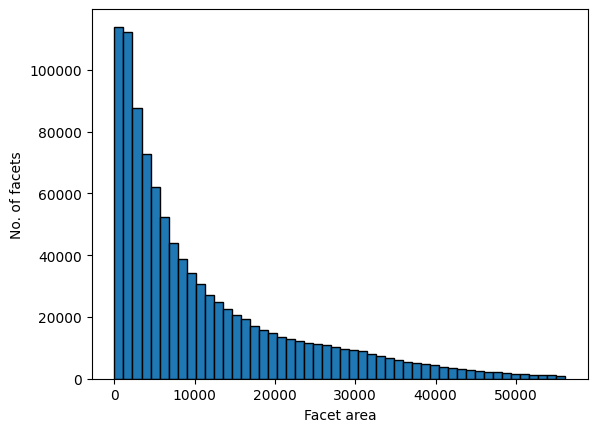

In [45]:
import numpy as np
import matplotlib.pyplot as plt

data_dict = house_facet_area

# Combine all lists
combined = []
for lst in data_dict.values():
    combined.extend(lst)

combined = np.array(combined)

cutoff_percentage = 99
cutoff = np.percentile(combined,cutoff_percentage)

# Filter out values above the cutoff
filtered = combined[combined <= cutoff]

print(f"Cutoff value ({cutoff_percentage}th percentile): {cutoff}")
print("Original count:", len(combined), "Filtered count:", len(filtered))

# Plot histogram
plt.hist(filtered, bins=50, edgecolor='black')
plt.xlabel("Facet area")
plt.ylabel("No. of facets")
plt.show()


In [66]:
combined[:60]

array([ 1,  2,  3,  3,  4,  5,  5,  5,  7,  7,  7,  8,  8,  8,  8,  8,  9,
        9,  9,  9, 10, 11, 12, 13, 13, 14, 14, 14, 15, 15, 15, 15, 15, 15,
       16, 16, 16, 16, 16, 16, 16, 17, 17, 17, 17, 17, 17, 18, 18, 18, 18,
       18, 19, 19, 20, 20, 20, 20, 20, 20])

In [67]:
house_facets_info = {}
area_threshold = 1250
min_area = 10
for house_id,facets_areas in house_facet_area.items():
    facets_under_threshold = sum([area<area_threshold and area>min_area for area in facets_areas])
    total_facets = len(facets_areas)
    house_info = {'num_facets':total_facets, 'num_small_facets':facets_under_threshold}
    house_facets_info[house_id] = house_info

In [68]:
df = pd.DataFrame(house_facets_info).T
df = df.reset_index()
df = df.rename(columns = {'index':"image_id"})
df[(df['num_small_facets']>=1) & (df['num_facets']>=8)]

,image_id,num_facets,num_small_facets
3,76938,24,7
9,103137,9,2
12,23245,47,26
15,34704,11,3
17,108067,11,6
...,...,...,...
120527,118300,15,4
120537,71351,9,1
120541,252,11,1
120544,110624,9,1


In [48]:
(df[(df['num_small_facets']>=1) & (df['num_facets']>=8)])

,image_id,num_facets,num_small_facets
3,76938,24,7
9,103137,9,2
12,23245,47,26
15,34704,11,3
17,108067,11,6
...,...,...,...
120527,118300,15,4
120537,71351,9,1
120541,252,11,1
120544,110624,9,1


In [69]:
import json
from collections import defaultdict

target_image_ids = set(df[(df['num_small_facets']>=1) & (df['num_facets']>=8)].image_id)

filtered_images = [
    img for img in coco_data['images'] 
    if img['id'] in target_image_ids
]
kept_image_ids = {img['id'] for img in filtered_images}
filtered_annotations = [
    ann for ann in coco_data['annotations'] 
    if ann['image_id'] in kept_image_ids]

filtered_coco_data = {
    'images': filtered_images,
    'annotations': filtered_annotations,
    'categories': coco_data['categories'] 
}

output_file = '/mnt/harddrive/data/dataset/sam3_format/filtered_coco_min_8_facets_min_1_small_1250_threshold.json'
with open(output_file, 'w') as f:
    json.dump(filtered_coco_data, f, indent=4)
    

In [87]:
df[(df['num_small_facets']==0) & (df['num_facets']>=8)]

,image_id,num_facets,num_small_facets
0,23180,10,0
21,119763,9,0
24,106458,8,0
64,53938,15,0
75,22152,11,0
...,...,...,...
120513,92183,8,0
120514,79302,8,0
120531,97778,13,0
120532,96037,12,0


In [94]:
import json
from collections import defaultdict

target_image_ids = set(df[(df['num_small_facets']==0) & (df['num_facets']>=8)].image_id)

filtered_images = [
    img for img in coco_data['images'] 
    if img['id'] in target_image_ids
]
kept_image_ids = {img['id'] for img in filtered_images}
filtered_annotations = [
    ann for ann in coco_data['annotations'] 
    if ann['image_id'] in kept_image_ids]

filtered_coco_data = {
    'images': filtered_images,
    'annotations': filtered_annotations,
    'categories': coco_data['categories'] 
}

output_file = '/mnt/harddrive/data/dataset/sam3_format/filtered_coco_min_8_facets_0_small_1250_threshold.json'
with open(output_file, 'w') as f:
    json.dump(filtered_coco_data, f, indent=4)
    

In [272]:
len(filtered_coco_data['images'])

23560

In [293]:
gt_rles = []
for i in range(1,int(len(filtered_coco_data['images'])/100)):
    for ann in filtered_coco_data['annotations'][100*(i-1):100*i]:
        seg = ann['segmentation']
        gt_rles.append(seg)
        gt_masks_np = mask_util.decode(gt_rles) 
    print(100*i, sum(np.sum(gt_masks_np,axis=(0,1))<10))

100 0
200 0
300 0
400 0
500 0
600 0
700 0
800 0
900 0
1000 0
1100 0
1200 0
1300 0
1400 0
1500 0
1600 0
1700 0
1800 0
1900 0
2000 0
2100 0
2200 0
2300 0
2400 0
2500 0
2600 0
2700 0
2800 0
2900 0
3000 0
3100 0
3200 0
3300 0
3400 0
3500 0
3600 0
3700 0
3800 0
3900 0
4000 0
4100 0
4200 0
4300 0
4400 0
4500 0
4600 0
4700 0
4800 0
4900 0
5000 0
5100 0
5200 0
5300 0
5400 0
5500 0
5600 0
5700 0
5800 0
5900 0
6000 0
6100 0
6200 0
6300 0
6400 0
6500 0
6600 0
6700 0
6800 0
6900 0
7000 0
7100 0
7200 0
7300 0
7400 0
7500 0
7600 0
7700 0
7800 0
7900 0
8000 0
8100 0
8200 0
8300 0
8400 0
8500 0
8600 0
8700 0
8800 0
8900 0
9000 0


KeyboardInterrupt: 

In [284]:
gt_masks_np.shape

(1024, 1024, 100)

In [288]:
sum(np.sum(gt_masks_np,axis=(0,1))<10)

0

In [95]:
len(target_image_ids)

23560

In [73]:
import json
import pandas as pd
from typing import Dict, Any, Set, List

def filter_and_validate_coco(
    coco_data: Dict[str, Any], 
    df: pd.DataFrame, 
) -> Dict[str, Any]:
    """
    Filters COCO data based on DataFrame criteria and performs validation 
    to remove corrupted annotations (zero-area bounding boxes).

    Args:
        coco_data: The loaded COCO dictionary.
        df: DataFrame containing pre-calculated metrics ('num_facets', 'num_small_facets').
        input_path: Path to the original COCO file (for reference).
        output_path: Path to save the new, clean COCO file.

    Returns:
        The filtered COCO dictionary.
    """
    print(f"--- Starting Validation and Filtering ---")
    print(f"Original Annotations: {len(coco_data['annotations'])}")
    
    # --- 1. Filter Images based on DataFrame Criteria ---
    
    # Calculate the set of Image IDs that meet the complexity thresholds
    target_image_ids = set(
        df[(df['num_small_facets'] >= 1) & (df['num_facets'] >= 8)]['image_id']
    )
    
    # --- 2. Filter Annotations (Including Corruption Check) ---
    valid_annotations: List[Dict[str, Any]] = []
    removed_count = 0
    
    for ann in coco_data['annotations']:
        image_id = ann.get('image_id')
        bbox = ann.get('bbox')
        
        # A. Check if the image ID is in the target set
        if image_id not in target_image_ids:
            continue
        
        # B. Validation Check for Corruption
        # COCO bbox format: [x, y, width, height]
        width = bbox[2]
        height = bbox[3]
        
        # CRITICAL FIX: Remove all annotations where width or height is non-positive.
        if width <= 0 or height <= 0:
            removed_count += 1
            continue
            
        valid_annotations.append(ann)

    # --- 3. Final Assembly ---
    
    # Get the IDs of images that successfully retained at least one valid annotation
    kept_image_ids = {ann['image_id'] for ann in valid_annotations}
    
    # Filter the images list one final time
    filtered_images = [
        img for img in coco_data['images'] 
        if img['id'] in kept_image_ids
    ]
    
    # --- 4. Save and Report ---
    cleaned_coco_data = {
        'images': filtered_images,
        'annotations': valid_annotations,
        'categories': coco_data['categories'] 
    }

    # with open(output_path, 'w') as f:
        # json.dump(cleaned_coco_data, f, indent=4)
        
    print(f"\n--- Validation Summary ---")
    print(f"Total Corrupted/Filtered Annotations Removed: {removed_count}")
    print(f"Total Annotations Remaining: {len(valid_annotations)}")
    # print(f"Clean COCO file saved to: {output_path}")
    
    # return cleaned_coco_data

# --- EXAMPLE USAGE (UPDATE YOUR PATHS AND LOAD YOUR DF/COCO DATA) ---
# NOTE: You must ensure 'df' and 'coco_data' are loaded pandas DataFrame 
# and dictionary objects in your session before running this function.

# INPUT_JSON = '/path/to/original.json' 
# OUTPUT_JSON = '/mnt/harddrive/data/dataset/sam3_format/cleaned_validated_coco.json'
# coco_data = json.load(open(INPUT_JSON, 'r'))
# df = pd.read_csv('path/to/df.csv') 
# 
input_file = '/mnt/harddrive/data/dataset/sam3_format/filtered_coco_min_8_facets_min_1_small_1250_threshold.json'
coco_data = json.load(open(input_file, 'r'))

filter_and_validate_coco(coco_data, df)

--- Starting Validation and Filtering ---
Original Annotations: 453227

--- Validation Summary ---
Total Corrupted/Filtered Annotations Removed: 0
Total Annotations Remaining: 453227


In [81]:
(coco_data['images'])[0]

{'id': 76938,
 'file_name': '1025980_26_023359_-80_331516.jpg',
 'height': 1024,
 'width': 1024}

In [85]:
for idx,image_data in enumerate(coco_data['images']):
    if image_data['file_name'] not in os.listdir('/mnt/harddrive/data/dataset/sam2_format/rgb_resized/'):
        print(image_data)
    if idx%1000 == 0:
        print(idx)

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000


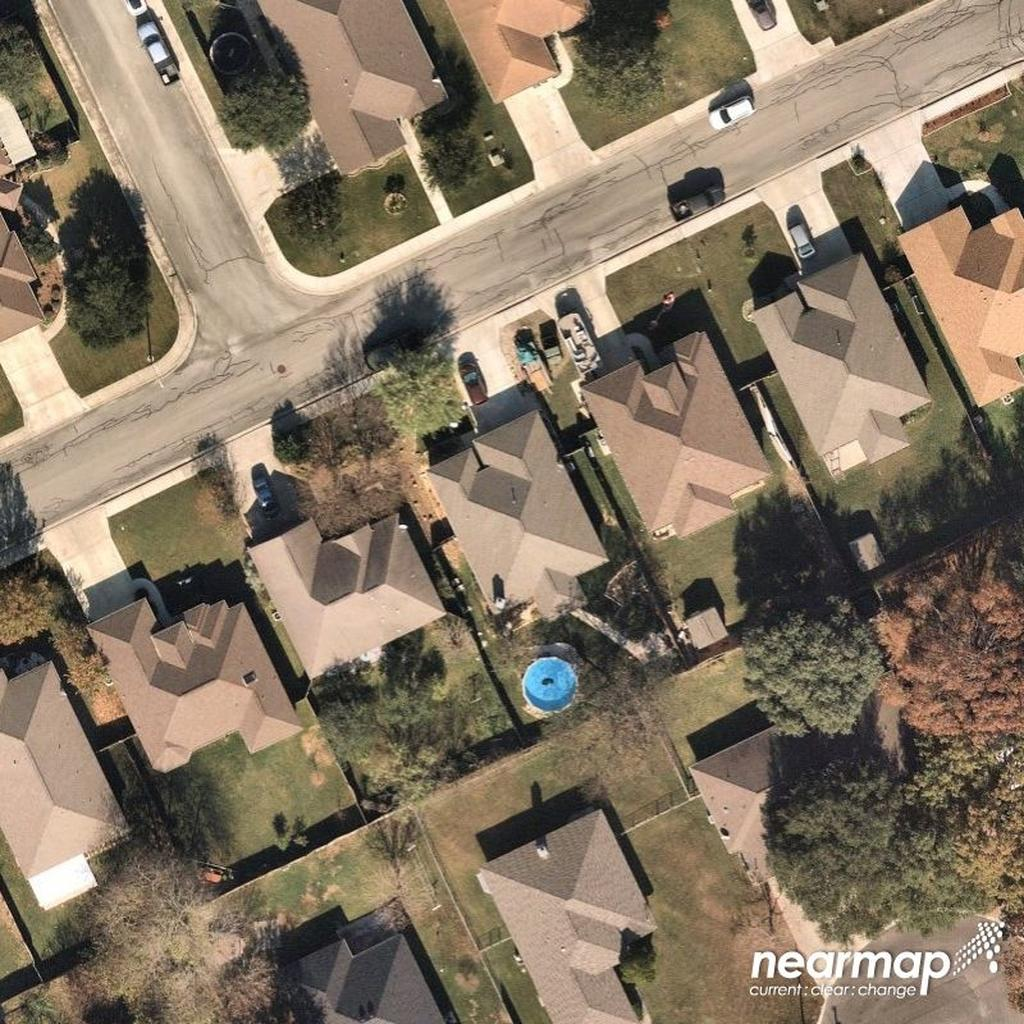

In [52]:
Image.open('/mnt/harddrive/data/dataset/sam2_format/rgb_resized/'+coco_data['images'][17]['file_name'])

In [104]:
df[(df['num_facets']<4) & (df['num_small_facets']!=0)]

,image_id,num_facets,num_small_facets
350,101210,3,1
401,62537,3,1
579,81350,3,1
700,32819,3,1
877,54499,3,1
...,...,...,...
118412,112507,3,1
118997,5485,3,1
119018,105401,3,1
119784,20274,3,1


In [90]:
coco_data['images'][1]

{'id': 93793,
 'file_name': '1011525_30_403343_-90_157723.jpg',
 'height': 1024,
 'width': 1024}